<a href="https://www.kaggle.com/code/sonawanelalitsunil/ice-cream-sales-vs-weather-analysis-ml-96-91?scriptVersionId=227394919" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ice-cream-sales-analysis-temperature-and-weather/Icecream Sales wr Rain and Temperature.csv


## Title: Ice Cream Sales vs. Weather Analysis

#### Description: Analyzing the impact of temperature and weather conditions on ice cream sales to identify trends, seasonal patterns, and optimal selling conditions.

In [2]:
df = pd.read_csv('/kaggle/input/ice-cream-sales-analysis-temperature-and-weather/Icecream Sales wr Rain and Temperature.csv')

In [3]:
df.head()

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)",Did it rain on that day?
0,80.6,1.0,89.5,90,No
1,75.2,1.0,86.4,85,No
2,86.0,2.0,99.2,107,No
3,75.2,2.0,72.4,71,Yes
4,60.8,2.0,71.2,65,Yes


In [4]:
df.tail()

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)",Did it rain on that day?
15,64.4,0.75,52.1,53,Yes
16,71.6,0.75,88.4,75,Yes
17,86.0,0.75,95.2,99,No
18,78.8,2.00,81.9,81,No
19,77.0,2.00,87.9,88,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (F)                 20 non-null     float64
 1   Ice-cream Price ($)             20 non-null     float64
 2   Number of Tourists (thousands)  20 non-null     float64
 3   Ice Cream Sales ($,thousands)   20 non-null     int64  
 4   Did it rain on that day?        20 non-null     object 
dtypes: float64(3), int64(1), object(1)
memory usage: 928.0+ bytes


In [6]:
df.describe()

,Temperature (F),Ice-cream Price ($),Number of Tourists (thousands),"Ice Cream Sales ($,thousands)"
count,20.000000,20.000000,20.000000,20.000000
mean,73.130000,1.362500,78.955000,76.850000
std,7.598137,0.496534,10.992556,13.259654
min,60.800000,0.750000,52.100000,53.000000
25%,67.550000,1.000000,71.175000,66.750000
50%,75.200000,1.375000,76.600000,74.000000
75%,78.800000,2.000000,88.025000,85.750000
max,86.000000,2.000000,99.200000,107.000000


In [7]:
df.isnull().sum()

Temperature (F)                   0
Ice-cream Price ($)               0
Number of Tourists (thousands)    0
Ice Cream Sales ($,thousands)     0
Did it rain on that day?          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Temperature (F)                   float64
Ice-cream Price ($)               float64
Number of Tourists (thousands)    float64
Ice Cream Sales ($,thousands)       int64
Did it rain on that day?           object
dtype: object

In [10]:
df.columns

Index(['Temperature (F)', 'Ice-cream Price ($)',
       'Number of Tourists (thousands)', 'Ice Cream Sales ($,thousands)',
       'Did it rain on that day?'],
      dtype='object')

## Data visualizations

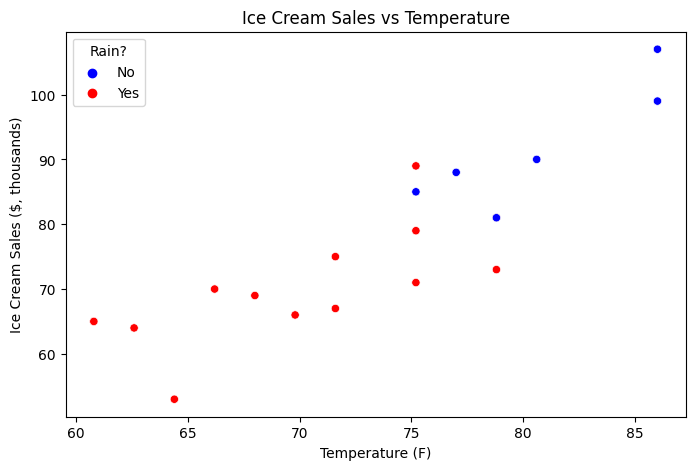

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Temperature (F)'], y=df['Ice Cream Sales ($,thousands)'], hue=df['Did it rain on that day?'], palette=['blue', 'red'])
plt.title("Ice Cream Sales vs Temperature")
plt.xlabel("Temperature (F)")
plt.ylabel("Ice Cream Sales ($, thousands)")
plt.legend(title="Rain?")
plt.show()

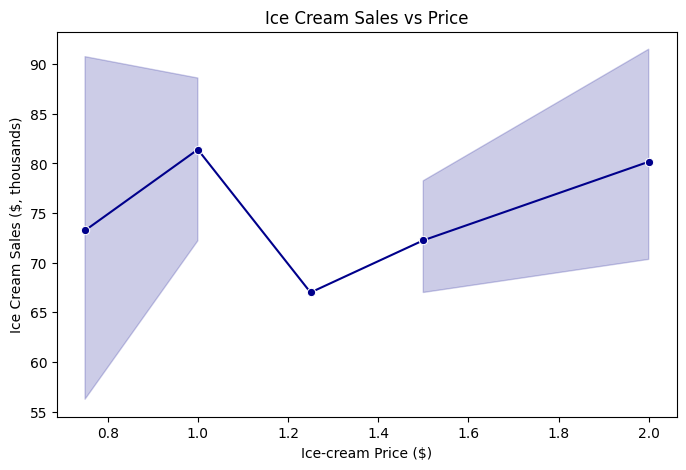

In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=df['Ice-cream Price ($)'], y=df['Ice Cream Sales ($,thousands)'], marker='o', color='darkblue')
plt.title("Ice Cream Sales vs Price")
plt.xlabel("Ice-cream Price ($)")
plt.ylabel("Ice Cream Sales ($, thousands)")
plt.show()

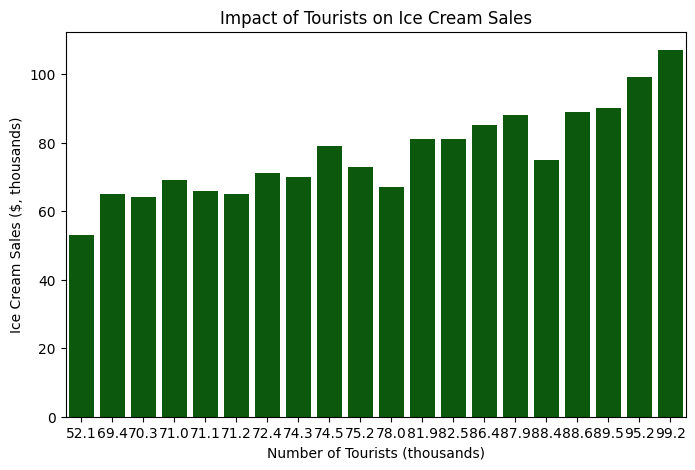

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Number of Tourists (thousands)'], y=df['Ice Cream Sales ($,thousands)'], color='darkgreen')
plt.title("Impact of Tourists on Ice Cream Sales")
plt.xlabel("Number of Tourists (thousands)")
plt.ylabel("Ice Cream Sales ($, thousands)")
plt.show()

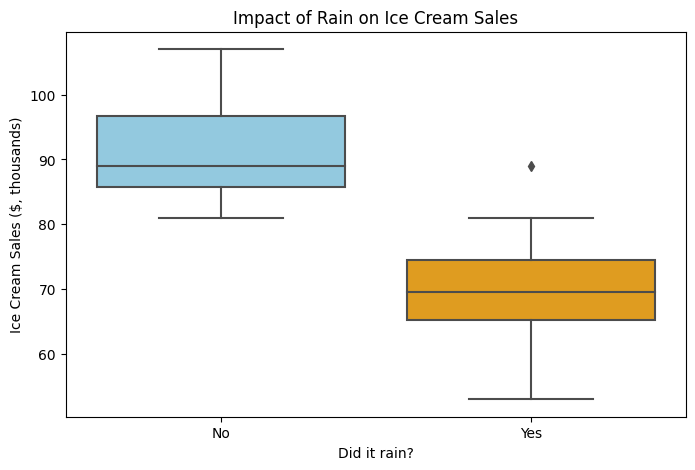

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Did it rain on that day?'], y=df['Ice Cream Sales ($,thousands)'], palette=['skyblue', 'orange'])
plt.title("Impact of Rain on Ice Cream Sales")
plt.xlabel("Did it rain?")
plt.ylabel("Ice Cream Sales ($, thousands)")
plt.show()

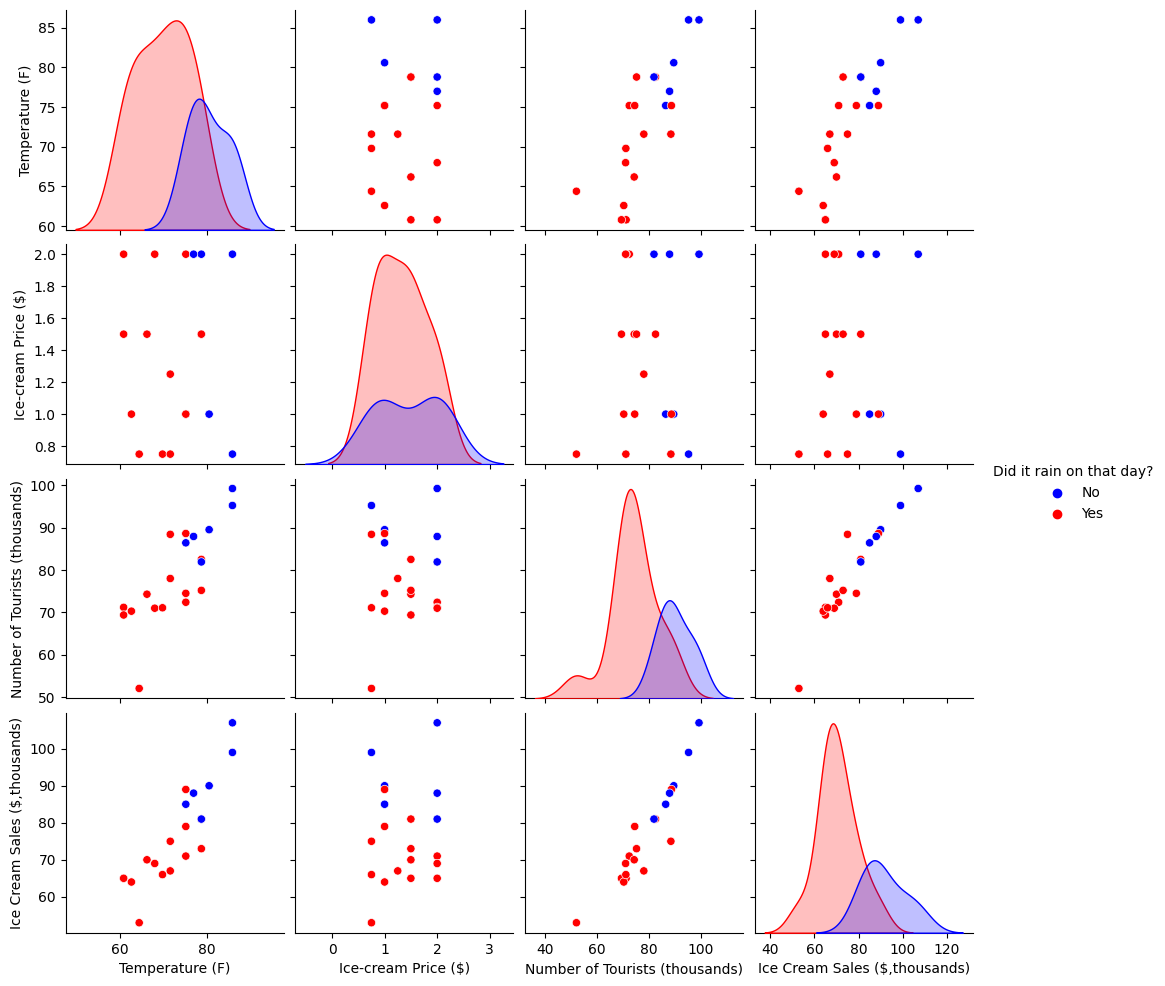

In [15]:
sns.pairplot(df, hue='Did it rain on that day?', palette=['blue', 'red'])
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
label_encoder = LabelEncoder()
df['Did it rain on that day?'] = label_encoder.fit_transform(df['Did it rain on that day?'])

X = df.drop(columns=['Ice Cream Sales ($,thousands)'])
y = df['Ice Cream Sales ($,thousands)']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"{name}: MAE = {mae:.2f}, MSE = {mse:.2f}")

Linear Regression: MAE = 2.23, MSE = 9.29
Random Forest: MAE = 3.82, MSE = 43.20
Support Vector Regression: MAE = 17.85, MSE = 346.54
K-Nearest Neighbors: MAE = 8.15, MSE = 99.07
Decision Tree: MAE = 8.00, MSE = 70.50


In [18]:
from sklearn.metrics import r2_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred) * 100  
    
    print(f"{name}: R² Score = {r2:.2f}%")

Linear Regression: R² Score = 96.91%
Random Forest: R² Score = 85.63%
Support Vector Regression: R² Score = -15.25%
K-Nearest Neighbors: R² Score = 67.05%
Decision Tree: R² Score = 76.55%


## Thank you...!!!!